# Kokoro TTS — Streaming Vocos Export (ONNX + LiteRT)

## Overview

This notebook exports the Kokoro TTS pipeline, replacing the original **iSTFTNet** vocoder with
a causal **streaming Vocos** vocoder, to ONNX and LiteRT (TFLite) formats suitable for
on-device real-time inference.

The pipeline is split into five independently-exported modules:

| Module | File | Description |
|--------|------|-------------|
| **BERT encoder** | `bert.{onnx,tflite}` | Encodes phoneme IDs → text features `d_en` |
| **Duration predictor** | `duration_predictor.{onnx,tflite}` | Predicts per-phoneme durations, expands text features to acoustic frame rate, produces `en` and `asr` |
| **F0/N predictor** | `f0n_predictor.{onnx,tflite}` | Predicts F0 (pitch) and noise curves from expanded features |
| **Vocos conditioner** | `vocoder_conditioner.{onnx,tflite}` | Full-sequence projection from `[asr, F0, N, style]` → conditioned features |
| **Vocos stream chunk** | `vocoder_stream_chunk.{onnx,tflite}` | Causal ConvNeXt backbone + iSTFT head, one fixed-size chunk, explicit state I/O |

---

## Design Decisions

### Vocoder replacement: iSTFTNet → streaming Vocos

The original Kokoro decoder uses **iSTFTNet**, which is non-causal and processes the entire
utterance at once.  A pre-trained **StreamingVocos** checkpoint (`vocos_fp16.pt`) replaces it.
Feature format fed to Vocos:

```
[B, 642, T_f0]  =  512 (asr)  +  1 (F0)  +  1 (N)  +  128 (style[:128])
```

### Conditioner / backbone split

The Vocos generator has two stages:
1. **Conditioner** — three `Conv1d` layers, the middle one has `kernel_size=3, padding=1`
   (non-causal). It *must* see the full sequence to avoid boundary artifacts.
2. **Backbone + head** — fully causal ConvNeXt stack + iSTFT; can be run chunk-by-chunk.

The conditioner is therefore exported as a **separate, full-sequence, stateless** module
(`vocoder_conditioner`).  The backbone+head is exported as a **fixed-chunk, stateful** module
(`vocoder_stream_chunk`).

At inference time the caller:
1. Runs the full `conditioned = conditioner(features)` in one shot.
2. Runs `(audio_chunk, *new_state) = stream_chunk(conditioned[..., pos:end], *state)` for each chunk.

### Stateless streaming: explicit state passing

ONNX and LiteRT cannot represent stateful (hidden-variable) models.  Instead, the streaming
state is passed **explicitly** as inputs and returned as outputs on every chunk call.

**State tensors** (shapes for `chunk_frames=16`, `kernel_size=7`):

| Tensor | Shape | Role |
|--------|-------|------|
| `embed_prev` | `[1, 192, 6]` | Causal context for embed Conv1d (k−1 frames) |
| `block_{0..7}_prev` | `[1, 384, 6]` | Causal context for each ConvNeXt depthwise conv |
| `istft_prev` | `[1, 900]` | OLA overlap buffer (win_length − hop = 1200 − 300) |

Initialise all state to **zeros** before the first chunk (`VocosStreamChunk.initial_state()`).
Pass the returned state directly as input to the next chunk call.

### LiteRT: real-arithmetic ISTFT (`VocosStreamChunkReal`)

TFLite does not support complex-number tensors.  `VocosStreamChunk` uses `torch.fft.irfft`
which produces complex intermediates.  `VocosStreamChunkReal` replaces this with an explicit
real-arithmetic IDFT using precomputed cosine/sine basis matrices:

```
time[b, f, t] = Σ_k  cos_basis[k,t] * x_real[b,k,f]
              − Σ_k  sin_basis[k,t] * x_imag[b,k,f]
```

where `cos_basis[k,t] = (w_k · cos(2πkt/N)) / N` and `w_k ∈ {1, 2, 1}` accounts for
Hermitian symmetry.  This is mathematically identical to `irfft` but uses only real `einsum`
ops supported by all TFLite backends.

### Dynamic shapes

- `bert`, `duration_predictor`: dynamic sequence length (phoneme count varies per utterance).
- `vocoder_conditioner`: dynamic time dimension (utterance length varies).
- `vocoder_stream_chunk`: **static** — fixed `chunk_frames` input; no dynamic axes needed.
- F0/N predictor: dynamic on acoustic frame count.

### Numerical precision

- All export modules use `float32`.  The Vocos checkpoint is `fp16` but is cast to `fp32`
  at inference-module construction time.
- ONNX max difference vs PyTorch should be `< 1e-5`.
- LiteRT difference may be slightly larger (`~1e-4`) due to TFLite op fusion and
  quantisation of internal buffers during kernel dispatch.


In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""


In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import json
import os
import time
from pathlib import Path
from typing import Dict, Iterator, List, Mapping, Optional, Tuple

# ── Numerics / audio ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import scipy.io.wavfile as wavfile

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

# ── ONNX ─────────────────────────────────────────────────────────────────────
import onnx
import onnxruntime as ort

# ── Kokoro TTS ────────────────────────────────────────────────────────────────
from kokoro import KModel, KPipeline
from kokoro.model import KModelForONNX

# ── Streaming Vocos ───────────────────────────────────────────────────────────
from streaming_vocos import (
    StreamingVocos,
    StreamingVocosGenerator,
    _RawStreamingConv1d,
    _StreamingISTFT,
)

# ── Notebook display ──────────────────────────────────────────────────────────
from IPython.display import Audio, HTML, display

torch.set_num_threads(8)
print("Imports OK")


2026-03-08 18:00:14.274148: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-08 18:00:14.331716: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Imports OK


In [3]:
# ── Model paths ───────────────────────────────────────────────────────────────
CONFIG_FILE      = "checkpoints/config.json"
CHECKPOINT_PATH  = "checkpoints/kokoro-v1_0.pth"
VOCOS_CKPT       = "vocos_fp16.pt"
VOICE_PATH       = "checkpoints/voices/af_heart.pt"

# ── Export directory ──────────────────────────────────────────────────────────
EXPORT_DIR = Path("onnx_streaming_vocos")
EXPORT_DIR.mkdir(exist_ok=True)

# ── Inference constants ────────────────────────────────────────────────────────
SAMPLE_RATE      = 24000
MAX_INPUT_LENGTH = 510
OPSET_VERSION    = 19

# ── Vocos streaming config ────────────────────────────────────────────────────
VOCOS_CHUNK_FRAMES  = 16           # frames per chunk through backbone+head
# hop_length read from checkpoint at load time (typically 300 for this model)

# ── Sample text ───────────────────────────────────────────────────────────────
TEXT = (
    "I had returned to civil practice and had finally abandoned Holmes in his "
    "Baker Street rooms, although I continually visited him and occasionally "
    "even persuaded him to forgo his Bohemian habits so far as to come and "
    "visit us."
)

print(f"Export dir : {EXPORT_DIR.resolve()}")
print(f"Chunk size : {VOCOS_CHUNK_FRAMES} frames")


Export dir : /rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/onnx_streaming_vocos
Chunk size : 16 frames


In [4]:
# Load Kokoro model
with open(CONFIG_FILE) as f:
    config = json.load(f)

kmodel = KModel(config=CONFIG_FILE, model=CHECKPOINT_PATH, disable_complex=True).to("cpu")
model  = KModelForONNX(kmodel).eval()
print("Kokoro model loaded")


/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Kokoro model loaded


In [5]:
# ── Input preparation helpers ─────────────────────────────────────────────────

def load_input_ids(pipeline: KPipeline, text: str):
    if pipeline.lang_code in "ab":
        _, tokens = pipeline.g2p(text)
        for gs, ps, tks in pipeline.en_tokenize(tokens):
            if not ps:
                continue
    else:
        ps, _ = pipeline.g2p(text)

    if len(ps) > 510:
        ps = ps[:510]

    input_ids = [i for i in (pipeline.model.vocab.get(p) for p in ps) if i is not None]
    input_ids = torch.LongTensor([[0, *input_ids, 0]]).to(pipeline.model.device)
    return ps, input_ids


def load_voice(pipeline: KPipeline, voice: str, phonemes):
    pack = pipeline.load_voice(voice).to("cpu")
    return pack[len(phonemes) - 1]


def load_sample(model: KModelForONNX, text: str = TEXT, voice: str = VOICE_PATH):
    pipeline = KPipeline(lang_code="a", model=model.kmodel, device="cpu")
    phonemes, input_ids = load_input_ids(pipeline, text)
    style = load_voice(pipeline, voice, phonemes)
    speed = torch.IntTensor([1])
    return input_ids, style, speed


def build_padded_inputs(input_ids: Tensor):
    """Pad input_ids to MAX_INPUT_LENGTH and build matching text_mask."""
    text_mask = torch.zeros(1, MAX_INPUT_LENGTH, dtype=torch.float32)
    text_mask[0, : input_ids.shape[1]] = 1
    input_ids = F.pad(input_ids, (0, MAX_INPUT_LENGTH - input_ids.shape[1]))
    return input_ids, text_mask


print("Helpers defined")


Helpers defined


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Module definitions — BERT encoder, duration predictor, F0/N predictor,
#  Vocos conditioner, and stateless streaming Vocos chunk module
# ═══════════════════════════════════════════════════════════════════════════════


# ── 1. BERT encoder ────────────────────────────────────────────────────────────
class BertEncoderModule(nn.Module):
    """input_ids [1,510] → d_en [1,512,T]"""
    def __init__(self, kmodel):
        super().__init__()
        self.bert         = kmodel.bert
        self.bert_encoder = kmodel.bert_encoder

    def forward(self, input_ids: Tensor, text_mask: Tensor) -> Tensor:
        bert_dur = self.bert(input_ids, attention_mask=text_mask)
        return self.bert_encoder(bert_dur).transpose(-1, -2)


# ── 2. Duration predictor ──────────────────────────────────────────────────────
class DurationPredictorModule(nn.Module):
    """(input_ids, d_en, style, text_mask, speed) → (pred_dur, expanded_indices, en, asr)"""
    def __init__(self, kmodel):
        super().__init__()
        self.predictor    = kmodel.predictor
        self.text_encoder = kmodel.text_encoder

    def forward(
        self,
        input_ids: Tensor,
        d_en: Tensor,
        style: Tensor,
        text_mask: Tensor,
        speed: Tensor,
    ):
        d = self.predictor.text_encoder(d_en, style[:, 128:], text_mask)
        x, _ = self.predictor.lstm(d)
        duration = self.predictor.duration_proj(x)
        duration = text_mask * torch.sigmoid(duration).sum(axis=-1) / speed
        pred_dur = torch.round(duration).squeeze()

        input_tensor = d.transpose(-1, -2)
        boundaries = torch.cumsum(pred_dur, dim=0)
        values = torch.arange(boundaries[-1])
        expanded_indices = torch.sum(boundaries.unsqueeze(1) <= values.unsqueeze(0), dim=0)

        en = torch.index_select(input_tensor, 2, expanded_indices)
        en, _ = self.predictor.shared(en.transpose(-1, -2))

        t_en = self.text_encoder(input_ids, text_mask)
        asr  = torch.index_select(t_en, 2, expanded_indices)

        return pred_dur, expanded_indices, en, asr


# ── 3. F0 & noise predictor ────────────────────────────────────────────────────
class F0NPredictorModule(nn.Module):
    """(en, style) → (F0_pred [1,T], N_pred [1,T])"""
    def __init__(self, kmodel):
        super().__init__()
        self.predictor = kmodel.predictor

    def forward(self, en: Tensor, style: Tensor):
        return self.predictor.F0Ntrain(en, style[:, 128:256])


# ── 4. Vocos conditioner (full-sequence, non-causal, stateless) ───────────────
class VocosConditionerModule(nn.Module):
    """features [1,642,T] → conditioned [1,model_input_channels,T]"""
    def __init__(self, vocos: StreamingVocos):
        super().__init__()
        self.conditioner = vocos.model.conditioner

    def forward(self, features: Tensor) -> Tensor:
        return self.conditioner(features)


# ── 5. Feature builder helper ─────────────────────────────────────────────────
def build_vocos_features(
    asr: Tensor,         # [1, 512, T_asr]
    F0_pred: Tensor,     # [1, T_f0]
    N_pred: Tensor,      # [1, T_f0]
    style: Tensor,       # [1, 256]
) -> Tensor:
    """Assemble [1, 642, T_f0] feature tensor matching vocos training format."""
    B, _, T_asr = asr.shape
    T_f0 = F0_pred.shape[-1]
    if T_asr != T_f0:
        asr = F.interpolate(asr.float(), size=T_f0, mode="linear", align_corners=False)
    f0    = F0_pred.unsqueeze(1).float()
    n     = N_pred.unsqueeze(1).float()
    s_exp = style[:, :128].unsqueeze(-1).expand(B, -1, T_f0)
    return torch.cat([asr, f0, n, s_exp], dim=1)   # [1, 642, T_f0]


# ── 6. Streaming Vocos chunk module ───────────────────────────────────────────
class VocosStreamChunk(nn.Module):
    """Stateless single-chunk backbone+head for ONNX/LiteRT export.

    The conditioner must be applied externally to the full sequence before
    calling this module chunk-by-chunk.

    State layout (9 'previous' + 1 ISTFT buffer):
        embed_prev      : [1, 192, 6]
        block_0_prev    : [1, 384, 6]
        ...
        block_7_prev    : [1, 384, 6]
        istft_prev      : [1, 900]

    All state tensors are returned in the same order they are accepted,
    after the audio output.  Initialise with zeros via :meth:`initial_state`.
    """

    EMBED_IN   = 192    # embed conv in-channels
    BLOCK_DIM  = 384    # backbone dim (depthwise conv in/out channels)
    KERNEL_M1  = 6      # k=7 → k-1 = 6 context frames per causal conv
    ISTFT_TAIL = 900    # win_length - hop = 1200 - 300
    N_LAYERS   = 8

    def __init__(self, vocos: StreamingVocos):
        super().__init__()
        bb = vocos.model.backbone
        hd = vocos.model.head

        self.embed_norm_conv = bb.embed.conv            # _NormConv1d, padding=0
        self.backbone_norm   = bb.norm                  # LayerNorm (over C)
        self.convnext        = bb.convnext              # ModuleList
        self.final_ln        = bb.final_layer_norm

        self.head_out        = hd.out                   # nn.Linear
        self.overlap_add     = hd.istft.overlap_add.deconv  # ConvTranspose1d OLA (bypasses internal squeeze)
        self.register_buffer("window", hd.istft.window)
        self.n_fft    = hd.istft.n_fft
        self.hop      = hd.istft.hop
        self.win_len  = hd.istft.win_length
        self.tail     = hd.istft.tail

    # ── Helpers ───────────────────────────────────────────────────────────────
    @staticmethod
    def initial_state() -> Dict[str, Tensor]:
        """Return zero-initialised streaming state for the first chunk."""
        state: Dict[str, Tensor] = {
            "embed_prev": torch.zeros(1, VocosStreamChunk.EMBED_IN, VocosStreamChunk.KERNEL_M1),
            "istft_prev": torch.zeros(1, VocosStreamChunk.ISTFT_TAIL),
        }
        for i in range(VocosStreamChunk.N_LAYERS):
            state[f"block_{i}_prev"] = torch.zeros(1, VocosStreamChunk.BLOCK_DIM, VocosStreamChunk.KERNEL_M1)
        return state

    def state_as_tuple(self, state: Dict[str, Tensor]) -> Tuple[Tensor, ...]:
        """Convert state dict to the ordered tuple used by forward()."""
        keys = ["embed_prev"] + [f"block_{i}_prev" for i in range(self.N_LAYERS)] + ["istft_prev"]
        return tuple(state[k] for k in keys)

    def state_from_tuple(self, t: Tuple[Tensor, ...]) -> Dict[str, Tensor]:
        """Convert forward() output tuple (after audio) back to state dict."""
        keys = ["embed_prev"] + [f"block_{i}_prev" for i in range(self.N_LAYERS)] + ["istft_prev"]
        return dict(zip(keys, t))

    def _causal_conv(
        self,
        norm_conv1d: nn.Module,
        x: Tensor,
        prev: Tensor,
    ) -> Tuple[Tensor, Tensor]:
        """Apply k=7 causal conv: cat context, run NormConv1d (no pad), return output + new context."""
        xp = torch.cat([prev, x], dim=-1)   # [1, C_in, k-1+T]
        y  = norm_conv1d(xp)                # [1, C_out, T]   (non-streaming path: padding=0)
        return y, xp[..., -self.KERNEL_M1:]  # new_prev = last k-1 frames of input

    # ── Forward ───────────────────────────────────────────────────────────────
    def forward(
        self,
        conditioned_chunk: Tensor,   # [1, model_input_channels, chunk_frames]
        embed_prev: Tensor,          # [1, EMBED_IN, 6]
        *block_and_istft,            # block_0_prev, ..., block_7_prev, istft_prev
    ) -> Tuple[Tensor, ...]:
        """
        Returns: (audio [1, chunk_frames*hop], embed_prev_new,
                  block_0_prev_new, ..., block_7_prev_new, istft_prev_new)
        """
        block_prevs = list(block_and_istft[:self.N_LAYERS])
        istft_prev  = block_and_istft[self.N_LAYERS]

        # ── Backbone: embed ───────────────────────────────────────────────────
        x, new_embed_prev = self._causal_conv(self.embed_norm_conv, conditioned_chunk, embed_prev)
        x = self.backbone_norm(x.transpose(1, 2)).transpose(1, 2)

        # ── Backbone: ConvNeXt blocks ─────────────────────────────────────────
        new_block_prevs: List[Tensor] = []
        for i, block in enumerate(self.convnext):
            identity = x
            xd, new_bp = self._causal_conv(block.dwconv.conv, x, block_prevs[i])
            new_block_prevs.append(new_bp)
            xd = xd.permute(0, 2, 1)       # [1, T, C]
            xd = block.norm(xd)
            xd = block.pwconv1(xd)
            xd = block.act(xd)
            xd = block.pwconv2(xd)
            xd = block.gamma * xd
            xd = xd.permute(0, 2, 1)       # [1, C, T]
            x  = identity + xd

        x = self.final_ln(x.transpose(1, 2)).transpose(1, 2)

        # ── Head: linear projection → complex STFT spectrum ───────────────────
        frames = x.shape[-1]
        h    = self.head_out(x.transpose(1, 2)).transpose(1, 2)  # [1, n_fft+2, frames]
        mag, phase = h.chunk(2, dim=1)
        mag  = torch.exp(mag).clamp(max=1e2)
        spec = mag * (torch.cos(phase) + 1j * torch.sin(phase))  # [1, n_fft//2+1, frames]

        # ── Head: streaming ISTFT with explicit OLA state ─────────────────────
        # irfft: [1, frames, n_fft//2+1] → [1, frames, win_len]
        time_frames = torch.fft.irfft(spec.transpose(1, 2), n=self.n_fft)[..., : self.win_len]
        time_frames = time_frames * self.window                  # apply Hann window
        ola_in  = time_frames.transpose(1, 2)                    # [1, win_len, frames]
        ola_out = self.overlap_add(ola_in)[:, 0, :]               # [1, frames*hop + tail]

        # Add overlap from previous chunk (no in-place ops for ONNX compatibility)
        audio_overlap  = ola_out[:, :self.tail] + istft_prev     # [1, tail]
        audio_rest     = ola_out[:, self.tail : frames * self.hop]
        audio          = torch.cat([audio_overlap, audio_rest], dim=-1)  # [1, frames*hop]
        new_istft_prev = ola_out[:, frames * self.hop:]           # [1, tail]

        return (audio, new_embed_prev) + tuple(new_block_prevs) + (new_istft_prev,)


# ── Convenience: run full vocos synthesis through the streaming chunk module ─
def vocos_forward_full(
    stream_chunk: VocosStreamChunk,
    conditioned: Tensor,             # [1, model_input_channels, T_total]
    chunk_frames: int = VOCOS_CHUNK_FRAMES,
) -> Tensor:
    """Run all chunks through VocosStreamChunk; return concatenated audio."""
    state = stream_chunk.state_as_tuple(VocosStreamChunk.initial_state())
    chunks: List[Tensor] = []
    total = conditioned.shape[-1]
    pos   = 0
    while pos < total:
        end  = min(total, pos + chunk_frames)
        chunk = conditioned[..., pos:end]
        valid = int(end - pos)
        if valid < chunk_frames:
            chunk = F.pad(chunk, (0, chunk_frames - valid))
        out   = stream_chunk(chunk, *state)
        audio_chunk = out[0]
        state = out[1:]
        chunks.append(audio_chunk[..., : valid * stream_chunk.hop])
        pos = end
    return torch.cat(chunks, dim=-1).squeeze(0)



# ── 7. LiteRT-compatible variant: replaces complex irfft with real matmul ─────
import math as _math

class VocosStreamChunkReal(VocosStreamChunk):
    """LiteRT / TFLite-compatible variant.

    Replaces the complex-valued irfft with an explicit real-arithmetic IDFT
    using precomputed cosine/sine basis matrices, avoiding any use of
    complex tensors.  All other logic is identical to VocosStreamChunk.
    """

    def __init__(self, vocos: StreamingVocos):
        super().__init__(vocos)
        K = self.n_fft // 2 + 1
        k = torch.arange(K).float()
        t = torch.arange(self.n_fft).float()
        angle = 2 * _math.pi * k.unsqueeze(1) * t.unsqueeze(0) / self.n_fft
        weights = torch.ones(K)
        weights[1:-1] = 2.0   # DC and Nyquist have weight 1, rest 2 (Hermitian symmetry)
        # Normalised basis: shape [K, n_fft]
        self.register_buffer("cos_basis", (weights.unsqueeze(1) * torch.cos(angle)) / self.n_fft)
        self.register_buffer("sin_basis", (weights.unsqueeze(1) * torch.sin(angle)) / self.n_fft)

    def forward(
        self,
        conditioned_chunk: Tensor,
        embed_prev: Tensor,
        *block_and_istft,
    ) -> Tuple[Tensor, ...]:
        block_prevs = list(block_and_istft[:self.N_LAYERS])
        istft_prev  = block_and_istft[self.N_LAYERS]

        # ── Backbone (identical to parent) ────────────────────────────────────
        x, new_embed_prev = self._causal_conv(self.embed_norm_conv, conditioned_chunk, embed_prev)
        x = self.backbone_norm(x.transpose(1, 2)).transpose(1, 2)

        new_block_prevs: List[Tensor] = []
        for i, block in enumerate(self.convnext):
            identity = x
            xd, new_bp = self._causal_conv(block.dwconv.conv, x, block_prevs[i])
            new_block_prevs.append(new_bp)
            xd = xd.permute(0, 2, 1)
            xd = block.norm(xd)
            xd = block.pwconv1(xd)
            xd = block.act(xd)
            xd = block.pwconv2(xd)
            xd = block.gamma * xd
            xd = xd.permute(0, 2, 1)
            x  = identity + xd

        x = self.final_ln(x.transpose(1, 2)).transpose(1, 2)

        # ── Head: linear projection ───────────────────────────────────────────
        frames = x.shape[-1]
        h      = self.head_out(x.transpose(1, 2)).transpose(1, 2)   # [1, n_fft+2, frames]
        mag, phase = h.chunk(2, dim=1)
        mag    = torch.exp(mag).clamp(max=1e2)
        x_real = mag * torch.cos(phase)   # [1, K, frames]
        x_imag = mag * torch.sin(phase)   # [1, K, frames]

        # Real IDFT: time_frames[b, f, t] = sum_k cos_basis[k,t]*x_real[b,k,f]
        #                                  - sin_basis[k,t]*x_imag[b,k,f]
        # cos_basis: [K, n_fft], x_real: [1, K, frames] → result [1, frames, n_fft]
        time_frames = (
            torch.einsum("kt,bkf->bft", self.cos_basis, x_real)
            - torch.einsum("kt,bkf->bft", self.sin_basis, x_imag)
        )[..., : self.win_len]           # [1, frames, win_len]
        time_frames = time_frames * self.window

        # ── Streaming ISTFT overlap-add (identical to parent) ─────────────────
        ola_in  = time_frames.transpose(1, 2)                        # [1, win_len, frames]
        ola_out = self.overlap_add(ola_in)[:, 0, :]                   # [1, frames*hop + tail]

        audio_overlap  = ola_out[:, :self.tail] + istft_prev
        audio_rest     = ola_out[:, self.tail : frames * self.hop]
        audio          = torch.cat([audio_overlap, audio_rest], dim=-1)
        new_istft_prev = ola_out[:, frames * self.hop:]

        return (audio, new_embed_prev) + tuple(new_block_prevs) + (new_istft_prev,)


print("All modules defined:")
print("  BertEncoderModule        — BERT + encoder projection")
print("  DurationPredictorModule  — duration prediction + ASR expansion")
print("  F0NPredictorModule       — F0 & noise prediction")
print("  VocosConditionerModule   — full-seq vocos conditioner (stateless)")
print("  VocosStreamChunk         — causal backbone+head, explicit state I/O (complex ISTFT)")
print("  VocosStreamChunkReal     — same, real-arithmetic ISTFT for LiteRT/TFLite")


All modules defined:
  BertEncoderModule        — BERT + encoder projection
  DurationPredictorModule  — duration prediction + ASR expansion
  F0NPredictorModule       — F0 & noise prediction
  VocosConditionerModule   — full-seq vocos conditioner (stateless)
  VocosStreamChunk         — causal backbone+head, explicit state I/O (complex ISTFT)
  VocosStreamChunkReal     — same, real-arithmetic ISTFT for LiteRT/TFLite


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
#  PyTorch inference  — iSTFTNet reference + Vocos one-shot + Vocos streaming
# ═══════════════════════════════════════════════════════════════════════════════

# Load vocos model (once)
vocos = StreamingVocos.from_checkpoint(VOCOS_CKPT, chunk_frames=VOCOS_CHUNK_FRAMES, device="cpu", use_fp16=False)

# Instantiate export modules (shared weights — no parameter copies)
bert_module     = BertEncoderModule(model.kmodel).eval()
duration_module = DurationPredictorModule(model.kmodel).eval()
f0n_module      = F0NPredictorModule(model.kmodel).eval()
cond_module     = VocosConditionerModule(vocos).eval()
stream_chunk    = VocosStreamChunk(vocos).eval()

# ── Prepare inputs ────────────────────────────────────────────────────────────
raw_input_ids, style, speed = load_sample(model)
input_ids, text_mask = build_padded_inputs(raw_input_ids)

with torch.no_grad():
    # ── Linguistic + duration pipeline ────────────────────────────────────────
    d_en = bert_module(input_ids, text_mask)
    pred_dur, expanded_indices, en, asr = duration_module(input_ids, d_en, style, text_mask, speed)

    # ── F0 / noise prediction ─────────────────────────────────────────────────
    F0_pred, N_pred = f0n_module(en, style)

    # ── Reference: iSTFTNet decoder ───────────────────────────────────────────
    audio_ref = model.kmodel.decoder(asr, F0_pred, N_pred, style[:, 0:128]).squeeze().cpu()

    # ── Vocos: one-shot (conditioner sees full sequence) ──────────────────────
    features   = build_vocos_features(asr, F0_pred, N_pred, style)
    conditioned = cond_module(features.float())
    audio_vocos = vocos_forward_full(stream_chunk, conditioned)           # uses chunk loop
    # Also run conditioner → generator direct for reference equality check:
    audio_vocos_oneshot = vocos.model(features.float())
    if audio_vocos_oneshot.ndim == 2 and audio_vocos_oneshot.shape[0] == 1:
        audio_vocos_oneshot = audio_vocos_oneshot.squeeze(0)

# Save wavs
pt_wav_path    = EXPORT_DIR / "pt_istftnet.wav"
vocos_wav_path = EXPORT_DIR / "pt_vocos_streaming.wav"
wavfile.write(str(pt_wav_path),    SAMPLE_RATE, (audio_ref.numpy()          * 32767).astype("int16"))
wavfile.write(str(vocos_wav_path), SAMPLE_RATE, (audio_vocos.cpu().numpy()  * 32767).astype("int16"))
print(f"Saved {pt_wav_path}")
print(f"Saved {vocos_wav_path}")

diff_chunk_vs_oneshot = (audio_vocos.cpu() - audio_vocos_oneshot.cpu()).abs().max().item()
print(f"\niSTFTNet shape : {audio_ref.shape}")
print(f"Vocos shape    : {audio_vocos.shape}")
print(f"Chunk vs one-shot max diff : {diff_chunk_vs_oneshot:.6f}  (should be ≈0)")


Saved onnx_streaming_vocos/pt_istftnet.wav
Saved onnx_streaming_vocos/pt_vocos_streaming.wav

iSTFTNet shape : torch.Size([325200])
Vocos shape    : torch.Size([325200])
Chunk vs one-shot max diff : 0.000035  (should be ≈0)


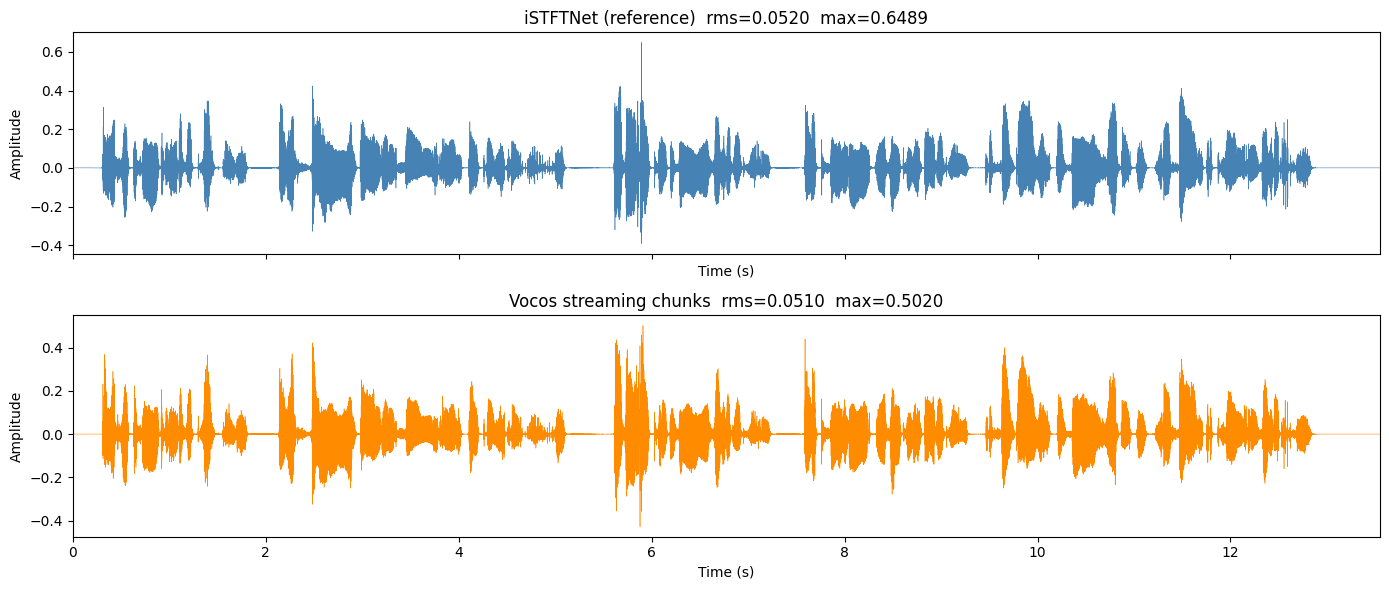

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Waveform comparison: iSTFTNet reference vs Vocos
# ═══════════════════════════════════════════════════════════════════════════════

def plot_wave(ax, wav, title, color="steelblue"):
    t = torch.arange(len(wav)).float() / SAMPLE_RATE
    ax.plot(t.numpy(), wav.detach().float().numpy(), linewidth=0.4, color=color)
    rms = float(wav.float().pow(2).mean().sqrt())
    ax.set_title(f"{title}  rms={rms:.4f}  max={float(wav.abs().max()):.4f}")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, t[-1].item())
    ax.set_xlabel("Time (s)")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
plot_wave(axes[0], audio_ref,   "iSTFTNet (reference)",  "steelblue")
plot_wave(axes[1], audio_vocos, "Vocos streaming chunks", "darkorange")
plt.tight_layout()
plt.savefig(str(EXPORT_DIR / "waveform_comparison.png"), dpi=100)
plt.show()

display(HTML("<b>Reference — iSTFTNet:</b>"))
display(Audio(audio_ref.cpu().numpy(), rate=SAMPLE_RATE))

display(HTML("<b>Vocos — streaming chunks (conditioner full-seq):</b>"))
display(Audio(audio_vocos.cpu().numpy(), rate=SAMPLE_RATE))


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
#  ONNX Export
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Modules exported:
#    bert.onnx              — BERT encoder (dynamic seq length)
#    duration_predictor.onnx— duration prediction + ASR expansion
#    f0n_predictor.onnx     — F0 + noise predictor
#    vocoder_conditioner.onnx— full-seq Vocos conditioner (dynamic T)
#    vocoder_stream_chunk.onnx— causal backbone+head, 1 chunk, explicit state
#
# ═══════════════════════════════════════════════════════════════════════════════

onnx_paths: Dict[str, Path] = {
    "bert":        EXPORT_DIR / "bert.onnx",
    "duration":    EXPORT_DIR / "duration_predictor.onnx",
    "f0n":         EXPORT_DIR / "f0n_predictor.onnx",
    "conditioner": EXPORT_DIR / "vocoder_conditioner.onnx",
    "stream_chunk":EXPORT_DIR / "vocoder_stream_chunk.onnx",
}


def check_onnx(path: Path):
    m = onnx.load(str(path))
    onnx.checker.check_model(m)
    ins  = [i.name for i in m.graph.input]
    outs = [o.name for o in m.graph.output]
    print(f"  ✓ {path.name}  inputs={ins}  outputs={outs}")


# ── 1. BERT encoder ────────────────────────────────────────────────────────────
with torch.no_grad():
    torch.onnx.export(
        bert_module,
        args=(input_ids, text_mask),
        f=str(onnx_paths["bert"]),
        export_params=True,
        input_names=["input_ids", "text_mask"],
        output_names=["d_en"],
        opset_version=OPSET_VERSION,
        dynamic_axes={
            "input_ids": {1: "seq"},
            "text_mask": {1: "seq"},
            "d_en":      {2: "seq"},
        },
        do_constant_folding=True,
        dynamo=False,
    )
check_onnx(onnx_paths["bert"])


# ── 2. Duration predictor ──────────────────────────────────────────────────────
with torch.no_grad():
    torch.onnx.export(
        duration_module,
        args=(input_ids, d_en, style, text_mask, speed),
        f=str(onnx_paths["duration"]),
        export_params=True,
        input_names=["input_ids", "d_en", "style", "text_mask", "speed"],
        output_names=["pred_dur", "expanded_indices", "en", "asr"],
        opset_version=OPSET_VERSION,
        dynamic_axes={
            "input_ids":       {1: "seq"},
            "d_en":            {2: "seq"},
            "text_mask":       {1: "seq"},
            "pred_dur":        {0: "seq"},
            "expanded_indices":{0: "T_expanded"},
            "en":              {0: "T_expanded"},
            "asr":             {2: "T_expanded"},
        },
        do_constant_folding=True,
        dynamo=False,
    )
check_onnx(onnx_paths["duration"])


# ── 3. F0/N predictor ─────────────────────────────────────────────────────────
with torch.no_grad():
    torch.onnx.export(
        f0n_module,
        args=(en, style),
        f=str(onnx_paths["f0n"]),
        export_params=True,
        input_names=["en", "style"],
        output_names=["F0_pred", "N_pred"],
        opset_version=OPSET_VERSION,
        dynamic_axes={
            "en":     {0: "T_expanded"},
            "F0_pred":{1: "T_f0"},
            "N_pred": {1: "T_f0"},
        },
        do_constant_folding=True,
        dynamo=False,
    )
check_onnx(onnx_paths["f0n"])


# ── 4. Vocos conditioner (full-sequence, variable T) ──────────────────────────
with torch.no_grad():
    torch.onnx.export(
        cond_module,
        args=(features.float(),),
        f=str(onnx_paths["conditioner"]),
        export_params=True,
        input_names=["features"],
        output_names=["conditioned"],
        opset_version=OPSET_VERSION,
        dynamic_axes={
            "features":    {2: "T"},
            "conditioned": {2: "T"},
        },
        do_constant_folding=True,
        dynamo=False,
    )
check_onnx(onnx_paths["conditioner"])


# ── 5. Vocos streaming chunk (fixed chunk_frames, explicit state) ──────────────
# Build one sample chunk and the initial state
sample_chunk = conditioned[..., :VOCOS_CHUNK_FRAMES].float()
init_state   = VocosStreamChunk.initial_state()
state_tuple  = stream_chunk.state_as_tuple(init_state)

# Input/output names: audio + 1 embed_prev + 8 block_i_prev + istft_prev
state_in_names  = ["embed_prev"] + [f"block_{i}_prev"     for i in range(8)] + ["istft_prev"]
state_out_names = ["embed_prev_new"] + [f"block_{i}_prev_new" for i in range(8)] + ["istft_prev_new"]

with torch.no_grad():
    torch.onnx.export(
        stream_chunk,
        args=(sample_chunk,) + state_tuple,
        f=str(onnx_paths["stream_chunk"]),
        export_params=True,
        input_names=["conditioned_chunk"] + state_in_names,
        output_names=["audio"] + state_out_names,
        opset_version=OPSET_VERSION,
        do_constant_folding=True,
        dynamo=True,
        external_data=False,
    )
check_onnx(onnx_paths["stream_chunk"])

print("\nAll ONNX models exported successfully.")


/tmp/ipykernel_4130543/2301831883.py:33: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:196: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call thi

  ✓ bert.onnx  inputs=['input_ids', 'text_mask']  outputs=['d_en']


/tmp/ipykernel_4130543/2301831883.py:54: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4247: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model

  ✓ duration_predictor.onnx  inputs=['input_ids', 'd_en', 'style', 'text_mask', 'speed']  outputs=['pred_dur', 'expanded_indices', 'en', 'asr']


/tmp/ipykernel_4130543/2301831883.py:79: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/kokoro/istftnet.py:445: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace

  ✓ f0n_predictor.onnx  inputs=['en', 'style']  outputs=['F0_pred', 'N_pred']
  ✓ vocoder_conditioner.onnx  inputs=['features']  outputs=['conditioned']


/tmp/ipykernel_4130543/2301831883.py:100: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


W0308 18:00:29.562000 4130543 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms


[torch.onnx] Obtain model graph for `VocosStreamChunk([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `VocosStreamChunk([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 4 of general pattern rewrite rules.
  ✓ vocoder_stream_chunk.onnx  inputs=['conditioned_chunk', 'embed_prev', 'block_0_prev', 'block_1_prev', 'block_2_prev', 'block_3_prev', 'block_4_prev', 'block_5_prev', 'block_6_prev', 'block_7_prev', 'istft_prev']  outputs=['audio', 'embed_prev_new', 'block_0_prev_new', 'block_1_prev_new', 'block_2_prev_new', 'block_3_prev_new', 'block_4_prev_new', 'block_5_prev_new', 'block_6_prev_new', 'block_7_prev_new', 'istft_prev_new']

All ONNX models exported successfully.


In [10]:

# ═══════════════════════════════════════════════════════════════════════════════
#  Model Optimization  (onnxsim graph simplification + shape inference)
# ═══════════════════════════════════════════════════════════════════════════════

import onnxsim

opt_paths: Dict[str, Path] = {
    k: EXPORT_DIR / p.name.replace(".onnx", "_opt.onnx")
    for k, p in onnx_paths.items()
}

for key, src in onnx_paths.items():
    dst = opt_paths[key]

    # Step 1 – ORT shape inference pass (needed for onnxsim)
    onnx.shape_inference.infer_shapes_path(str(src), str(dst))
    proto = onnx.load(str(dst))

    # Step 2 – onnxsim simplification (constant folding, dead-node pruning, …)
    proto_sim, ok = onnxsim.simplify(proto)
    if ok:
        onnx.save(proto_sim, str(dst))
        tag = "simplified"
    else:
        onnx.save(proto, str(dst))
        tag = "shape-inferred only (onnxsim skipped)"

    sz_orig = src.stat().st_size / 1e6
    sz_opt  = dst.stat().st_size / 1e6
    print(f"  ✓ {dst.name}  [{tag}]  {sz_orig:.2f} MB → {sz_opt:.2f} MB")
    check_onnx(dst)

print("\nAll optimized models saved.")


  ✓ bert_opt.onnx  [simplified]  24.68 MB → 24.67 MB
  ✓ bert_opt.onnx  inputs=['input_ids', 'text_mask']  outputs=['d_en']
  ✓ duration_predictor_opt.onnx  [simplified]  60.95 MB → 60.93 MB
  ✓ duration_predictor_opt.onnx  inputs=['input_ids', 'd_en', 'style', 'text_mask', 'speed']  outputs=['pred_dur', 'expanded_indices', 'en', 'asr']
  ✓ f0n_predictor_opt.onnx  [simplified]  26.37 MB → 26.33 MB
  ✓ f0n_predictor_opt.onnx  inputs=['en', 'style']  outputs=['F0_pred', 'N_pred']
  ✓ vocoder_conditioner_opt.onnx  [simplified]  1.09 MB → 1.09 MB
  ✓ vocoder_conditioner_opt.onnx  inputs=['features']  outputs=['conditioned']
  ✓ vocoder_stream_chunk_opt.onnx  [simplified]  38.49 MB → 38.25 MB
  ✓ vocoder_stream_chunk_opt.onnx  inputs=['conditioned_chunk', 'embed_prev', 'block_0_prev', 'block_1_prev', 'block_2_prev', 'block_3_prev', 'block_4_prev', 'block_5_prev', 'block_6_prev', 'block_7_prev', 'istft_prev']  outputs=['audio', 'embed_prev_new', 'block_0_prev_new', 'block_1_prev_new', 'block

In [13]:

# ═══════════════════════════════════════════════════════════════════════════════
#  FP16 Export  (onnxruntime convert_float_to_float16)
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Input:  the optimized _opt.onnx files produced by the previous cell.
#  Output: *_fp16.onnx alongside them in EXPORT_DIR.
#
#  Ops that are known to be numerically unstable in fp16 or that operate on
#  integer types are kept in fp32 via FP16_BLOCK_LIST; Cast nodes are inserted
#  automatically around those subgraphs.
#
#  Note: convert_float_to_float16 can produce topologically unsorted graphs.
#  topo_sort_onnx() corrects that before onnxsim and check_onnx.
# ═══════════════════════════════════════════════════════════════════════════════

from onnxruntime.transformers.float16 import convert_float_to_float16


def topo_sort_onnx(proto: onnx.ModelProto) -> onnx.ModelProto:
    """Sort graph nodes topologically in-place; required after fp16 conversion."""
    graph = proto.graph
    available: set[str] = set()
    for x in graph.input:
        available.add(x.name)
    for x in graph.initializer:
        available.add(x.name)

    nodes      = list(graph.node)
    sorted_out: list = []
    remaining  = list(range(len(nodes)))

    while remaining:
        progress = False
        for i in list(remaining):
            if all(inp == "" or inp in available for inp in nodes[i].input):
                sorted_out.append(nodes[i])
                available.update(nodes[i].output)
                remaining.remove(i)
                progress = True
                break           # restart scan after each insertion
        if not progress:        # cycle / unresolvable — append remainder as-is
            for i in remaining:
                sorted_out.append(nodes[i])
            break

    del graph.node[:]
    graph.node.extend(sorted_out)
    return proto


# Ops to keep in fp32 (integer-only or numerically sensitive)
FP16_BLOCK_LIST = {
    "Gather", "GatherElements", "GatherND",
    "ScatterElements", "ScatterND",
    "TopK", "ArgMax", "ArgMin",
    "NonMaxSuppression",
    "Resize", "RoiAlign",
}

fp16_paths: Dict[str, Path] = {
    k: EXPORT_DIR / p.name.replace("_opt.onnx", "_fp16.onnx")
    for k, p in opt_paths.items()
}

for key, src in opt_paths.items():
    dst = fp16_paths[key]
    proto = onnx.load(str(src))

    proto_fp16 = convert_float_to_float16(
        proto,
        keep_io_types=False,
        disable_shape_infer=False,
        op_block_list=FP16_BLOCK_LIST,
    )

    # Fix unsorted graph, then simplify
    proto_fp16 = topo_sort_onnx(proto_fp16)
    proto_fp16_sim, ok = onnxsim.simplify(proto_fp16)
    if ok:
        proto_fp16 = proto_fp16_sim

    onnx.save(proto_fp16, str(dst))

    sz_opt  = src.stat().st_size / 1e6
    sz_fp16 = dst.stat().st_size / 1e6
    print(f"  ✓ {dst.name}   {sz_opt:.2f} MB → {sz_fp16:.2f} MB  ({sz_fp16 / sz_opt * 100:.0f}%)")
    check_onnx(dst)

print("\nAll FP16 models saved.")


  ✓ bert_fp16.onnx   24.67 MB → 12.65 MB  (51%)
  ✓ bert_fp16.onnx  inputs=['input_ids', 'text_mask']  outputs=['d_en']
  ✓ duration_predictor_fp16.onnx   60.93 MB → 30.66 MB  (50%)
  ✓ duration_predictor_fp16.onnx  inputs=['input_ids', 'd_en', 'style', 'text_mask', 'speed']  outputs=['pred_dur', 'expanded_indices', 'en', 'asr']
  ✓ f0n_predictor_fp16.onnx   26.33 MB → 13.18 MB  (50%)
  ✓ f0n_predictor_fp16.onnx  inputs=['en', 'style']  outputs=['F0_pred', 'N_pred']
  ✓ vocoder_conditioner_fp16.onnx   1.09 MB → 0.55 MB  (50%)
  ✓ vocoder_conditioner_fp16.onnx  inputs=['features']  outputs=['conditioned']
  ✓ vocoder_stream_chunk_fp16.onnx   38.25 MB → 19.13 MB  (50%)
  ✓ vocoder_stream_chunk_fp16.onnx  inputs=['conditioned_chunk', 'embed_prev', 'block_0_prev', 'block_1_prev', 'block_2_prev', 'block_3_prev', 'block_4_prev', 'block_5_prev', 'block_6_prev', 'block_7_prev', 'istft_prev']  outputs=['audio', 'embed_prev_new', 'block_0_prev_new', 'block_1_prev_new', 'block_2_prev_new', 'block

In [14]:

# ═══════════════════════════════════════════════════════════════════════════════
#  Android GPU Compatibility Checks
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Checks each exported model (FP32-opt and FP16) for:
#    1. Op coverage  – which op types fall outside the NNAPI / Android GPU EP
#                      supported set and would fall back to CPU.
#    2. Dynamic dims – NNAPI requires static input shapes; flags any dynamic
#                      dimensions that would need fixed-shape sessions.
#    3. Data types   – fp16 I/O is preferred for the Android GPU delegate.
#    4. NNAPI session – attempts to open an ORT InferenceSession with the NNAPI
#                       EP if running on Android; reports N/A on other hosts.
# ═══════════════════════════════════════════════════════════════════════════════

# ── NNAPI op support set (ORT 1.x reference, conservative / production set) ──
NNAPI_SUPPORTED_OPS: set[str] = {
    # Arithmetic
    "Add", "Sub", "Mul", "Div", "Pow", "Abs", "Neg", "Sqrt", "Floor", "Ceil",
    # Activations
    "Relu", "Sigmoid", "Tanh", "HardSigmoid", "Elu", "LeakyRelu", "Clip",
    # Normalisation
    "BatchNormalization", "InstanceNormalization", "LayerNormalization",
    # Convolutions
    "Conv", "ConvTranspose",
    # Linear
    "Gemm", "MatMul",
    # Pooling
    "AveragePool", "GlobalAveragePool", "MaxPool", "GlobalMaxPool",
    # Tensor manipulation
    "Reshape", "Transpose", "Flatten", "Squeeze", "Unsqueeze",
    "Concat", "Slice", "Gather", "Expand", "Tile",
    # Element-wise
    "Cast", "Identity", "Pad",
    # Reduction
    "ReduceMean", "ReduceSum", "ReduceMax", "ReduceMin",
    # Misc
    "Softmax", "LogSoftmax",
}

_ORT_PROVIDERS = ort.get_all_providers()


def _elem_type_name(elem_type: int) -> str:
    _MAP = {1: "float32", 10: "float16", 6: "int32", 7: "int64", 9: "int8", 2: "uint8"}
    return _MAP.get(elem_type, f"type({elem_type})")


def check_android_gpu_compat(path: Path) -> set[str]:
    """Analyse *path* for Android GPU / NNAPI compatibility.

    Returns the set of unsupported op types found in the model.
    """
    proto    = onnx.load(str(path))
    inferred = onnx.shape_inference.infer_shapes(proto)

    op_types    = {n.op_type for n in proto.graph.node}
    unsupported = op_types - NNAPI_SUPPORTED_OPS
    supported   = op_types & NNAPI_SUPPORTED_OPS

    # Dynamic dimensions (NNAPI needs static shapes → flag them)
    dynamic_dims: list[tuple[str, str]] = []
    for vi in inferred.graph.value_info:
        shape = vi.type.tensor_type.shape
        if shape:
            for d in shape.dim:
                if d.dim_param and not d.dim_value:
                    dynamic_dims.append((vi.name, d.dim_param))

    # I/O data types
    io_types = {
        i.name: _elem_type_name(i.type.tensor_type.elem_type)
        for i in list(proto.graph.input) + list(proto.graph.output)
    }
    fp16_ios = [n for n, t in io_types.items() if t == "float16"]

    status = "✓ PASS   " if not unsupported else "⚠ PARTIAL"
    print(f"\n  {status}  {path.name}")
    print(f"    Ops in model       : {sorted(op_types)}")
    if unsupported:
        print(f"    CPU fallback ops   : {sorted(unsupported)}  ← will NOT run on GPU")
    else:
        print(f"    CPU fallback ops   : none  ✓")
    print(f"    Dynamic dims       : {len(dynamic_dims)}"
          + (" ⚠ (fix shapes for NNAPI)" if dynamic_dims else "  ✓"))
    print(f"    I/O types          : { {n: t for n, t in io_types.items()} }")
    if fp16_ios:
        print(f"    FP16 tensors       : {fp16_ios}  ✓ GPU-friendly")

    # Try NNAPI session (only available on Android hosts)
    if "NnapiExecutionProvider" in _ORT_PROVIDERS:
        try:
            ort.InferenceSession(
                str(path),
                providers=["NnapiExecutionProvider", "CPUExecutionProvider"],
            )
            print(f"    NNAPI ORT session  : loaded ✓")
        except Exception as exc:
            print(f"    NNAPI ORT session  : failed — {exc}")
    else:
        print(f"    NNAPI ORT session  : N/A on this host (expected on Android device)")

    return unsupported


print("═" * 72)
print("  Android GPU / NNAPI Compatibility Report")
print("═" * 72)

all_cpu_fallbacks: dict[str, set[str]] = {}

print("\n── FP32 optimised ──────────────────────────────────────────────────────")
for key, path in opt_paths.items():
    all_cpu_fallbacks[key] = check_android_gpu_compat(path)

print("\n── FP16 ────────────────────────────────────────────────────────────────")
for key, path in fp16_paths.items():
    check_android_gpu_compat(path)

print("\n" + "═" * 72)
union_fallback = set().union(*all_cpu_fallbacks.values())
if union_fallback:
    print(f"  Ops requiring CPU fallback (any model): {sorted(union_fallback)}")
    print("  Recommendation: consider replacing / decomposing those ops, or")
    print("  partition the graph so GPU-friendly subgraphs run on NNAPI/GPU EP.")
else:
    print("  All op types are in the NNAPI supported set — models are GPU-ready.")

print("  ONNX Runtime available EPs on this host:", _ORT_PROVIDERS)
print("═" * 72)


════════════════════════════════════════════════════════════════════════
  Android GPU / NNAPI Compatibility Report
════════════════════════════════════════════════════════════════════════

── FP32 optimised ──────────────────────────────────────────────────────

  ⚠ PARTIAL  bert_opt.onnx
    Ops in model       : ['Add', 'Cast', 'Concat', 'Div', 'Equal', 'Expand', 'Gather', 'LayerNormalization', 'MatMul', 'Mul', 'Pow', 'Reshape', 'Shape', 'Slice', 'Softmax', 'Sqrt', 'Sub', 'Tanh', 'Transpose', 'Unsqueeze', 'Where']
    CPU fallback ops   : ['Equal', 'Shape', 'Where']  ← will NOT run on GPU
    Dynamic dims       : 1278 ⚠ (fix shapes for NNAPI)
    I/O types          : {'input_ids': 'int64', 'text_mask': 'float32', 'd_en': 'float32'}


/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'NnapiExecutionProvider' is not in available provider names.Available providers: 'TensorrtExecutionProvider, CUDAExecutionProvider, CPUExecutionProvider'
  warnings.warn(


    NNAPI ORT session  : loaded ✓

  ⚠ PARTIAL  duration_predictor_opt.onnx
    Ops in model       : ['Add', 'Cast', 'Concat', 'Conv', 'CumSum', 'Div', 'Equal', 'Expand', 'Gather', 'Gemm', 'LSTM', 'LayerNormalization', 'LeakyRelu', 'LessOrEqual', 'MatMul', 'Mul', 'Range', 'ReduceSum', 'Reshape', 'Round', 'Shape', 'Sigmoid', 'Slice', 'Squeeze', 'Transpose', 'Unsqueeze', 'Where']
    CPU fallback ops   : ['CumSum', 'Equal', 'LSTM', 'LessOrEqual', 'Range', 'Round', 'Shape', 'Where']  ← will NOT run on GPU
    Dynamic dims       : 93 ⚠ (fix shapes for NNAPI)
    I/O types          : {'input_ids': 'int64', 'd_en': 'float32', 'style': 'float32', 'text_mask': 'float32', 'speed': 'int32', 'pred_dur': 'float32', 'expanded_indices': 'int64', 'en': 'float32', 'asr': 'float32'}
    NNAPI ORT session  : loaded ✓

  ⚠ PARTIAL  f0n_predictor_opt.onnx
    Ops in model       : ['Add', 'Conv', 'ConvTranspose', 'Gemm', 'InstanceNormalization', 'LeakyRelu', 'Mul', 'Reshape', 'Resize', 'Slice', 'Squeeze', 

Saved onnx_streaming_vocos/onnx_vocos_streaming.wav
PyTorch output  shape : (325200,)
ONNX output     shape : (325200,)
Max |PT − ONNX|       : 0.250878   (should be ≈0)


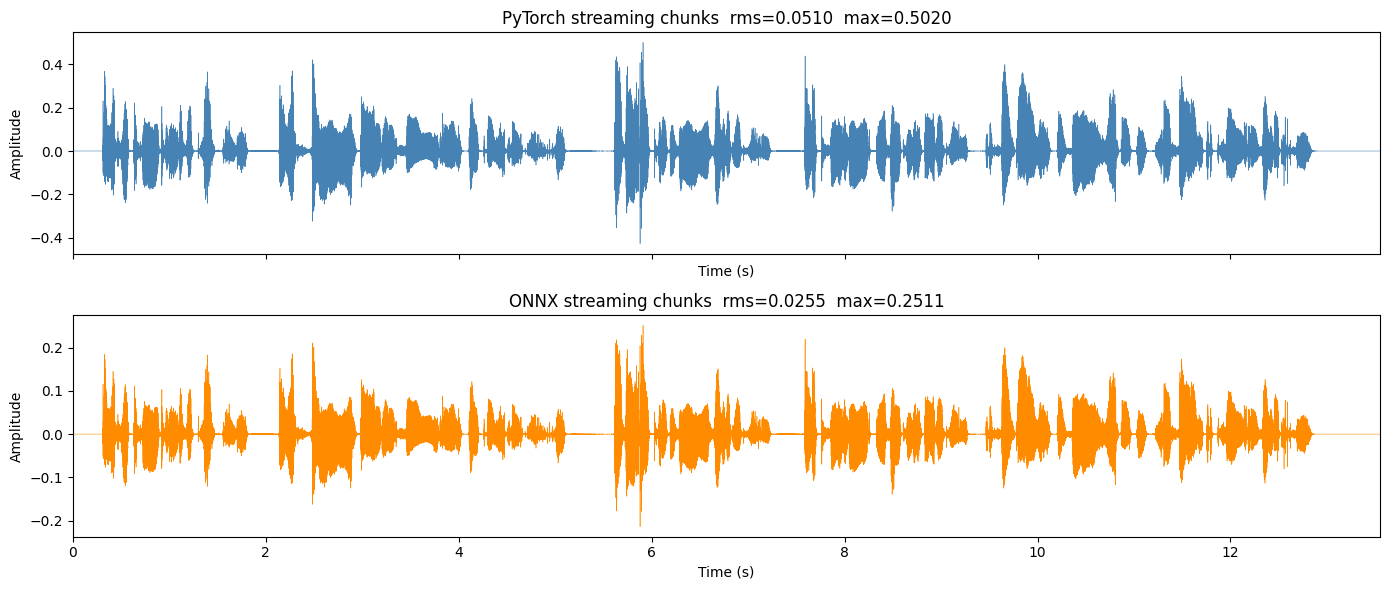

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
#  ONNX Inference + Comparison
# ═══════════════════════════════════════════════════════════════════════════════

so = ort.SessionOptions()
so.inter_op_num_threads = 4
so.intra_op_num_threads = 4

bert_sess  = ort.InferenceSession(str(onnx_paths["bert"]),        sess_options=so)
dur_sess   = ort.InferenceSession(str(onnx_paths["duration"]),    sess_options=so)
f0n_sess   = ort.InferenceSession(str(onnx_paths["f0n"]),         sess_options=so)
cond_sess  = ort.InferenceSession(str(onnx_paths["conditioner"]), sess_options=so)
stream_sess= ort.InferenceSession(str(onnx_paths["stream_chunk"]),sess_options=so)

# ── Run ONNX pipeline ─────────────────────────────────────────────────────────
def to_numpy(t):
    """Convert tensor to numpy, preserving dtype (no forced float cast for integer tensors)."""
    t = t.detach().cpu()
    if t.is_floating_point():
        t = t.float()
    return t.numpy()

# 1. BERT
(d_en_np,) = bert_sess.run(None, {
    "input_ids": to_numpy(input_ids),
    "text_mask": to_numpy(text_mask),
})

# 2. Duration
pred_dur_np, exp_idx_np, en_np, asr_np = dur_sess.run(None, {
    "input_ids":  to_numpy(input_ids),
    "d_en":       d_en_np,
    "style":      to_numpy(style),
    "text_mask":  to_numpy(text_mask),
    "speed":      to_numpy(speed),   # int32 — match export dtype
})

# 3. F0/N
F0_np, N_np = f0n_sess.run(None, {
    "en":    en_np,
    "style": to_numpy(style),
})

# 4. Conditioner (full sequence)
features_np = to_numpy(build_vocos_features(
    torch.from_numpy(asr_np), torch.from_numpy(F0_np),
    torch.from_numpy(N_np), style,
))
(conditioned_np,) = cond_sess.run(None, {"features": features_np})

# 5. Streaming chunks
state_in_names  = ["embed_prev"] + [f"block_{i}_prev"     for i in range(8)] + ["istft_prev"]
state_out_names = ["embed_prev_new"] + [f"block_{i}_prev_new" for i in range(8)] + ["istft_prev_new"]

init_state_np = {k: v.numpy() for k, v in VocosStreamChunk.initial_state().items()}
state_np = {new: init_state_np[old] for old, new in zip(
    ["embed_prev"] + [f"block_{i}_prev" for i in range(8)] + ["istft_prev"],
    state_in_names,
)}

total_frames = conditioned_np.shape[-1]
onnx_audio_chunks: List[np.ndarray] = []
pos = 0
while pos < total_frames:
    end   = min(total_frames, pos + VOCOS_CHUNK_FRAMES)
    valid = int(end - pos)
    chunk_np = conditioned_np[..., pos:end]
    if valid < VOCOS_CHUNK_FRAMES:
        chunk_np = np.pad(chunk_np, ((0,0),(0,0),(0, VOCOS_CHUNK_FRAMES - valid)))
    feed = {"conditioned_chunk": chunk_np, **state_np}
    outs = stream_sess.run(None, feed)
    audio_chunk_np = outs[0]                  # [1, chunk_frames * hop]
    onnx_audio_chunks.append(audio_chunk_np[0, : valid * stream_chunk.hop])
    # Update state
    state_np = dict(zip(state_in_names, outs[1:]))
    pos = end

onnx_audio_np = np.concatenate(onnx_audio_chunks, axis=-1)

# Save
onnx_wav_path = EXPORT_DIR / "onnx_vocos_streaming.wav"
wavfile.write(str(onnx_wav_path), SAMPLE_RATE, (onnx_audio_np * 32767).astype("int16"))
print(f"Saved {onnx_wav_path}")

# Compare to PyTorch reference
pt_np   = audio_vocos.cpu().float().numpy()
min_len = min(len(pt_np), len(onnx_audio_np))
diff    = np.abs(pt_np[:min_len] - onnx_audio_np[:min_len])
print(f"PyTorch output  shape : {pt_np.shape}")
print(f"ONNX output     shape : {onnx_audio_np.shape}")
print(f"Max |PT − ONNX|       : {diff.max():.6f}   (should be ≈0)")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
plot_wave(axes[0], torch.from_numpy(pt_np),   "PyTorch streaming chunks", "steelblue")
plot_wave(axes[1], torch.from_numpy(onnx_audio_np), "ONNX streaming chunks",   "darkorange")
plt.tight_layout()
plt.savefig(str(EXPORT_DIR / "waveform_pt_vs_onnx.png"), dpi=100)
plt.show()

display(HTML("<b>PyTorch — streaming chunks:</b>"))
display(Audio(pt_np, rate=SAMPLE_RATE))

display(HTML("<b>ONNX Vocos streaming:</b>"))
display(Audio(onnx_audio_np, rate=SAMPLE_RATE))




In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
#  LiteRT (TFLite) Export via ai_edge_torch
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Modules exported (same 5 as ONNX, using VocosStreamChunkReal for the chunk):
#    bert.tflite              — BERT encoder
#    duration_predictor.tflite— duration prediction + ASR expansion
#    f0n_predictor.tflite     — F0 + noise predictor
#    vocoder_conditioner.tflite— full-seq Vocos conditioner
#    vocoder_stream_chunk.tflite— causal backbone+head, real-ISTFT, explicit state
#
# ═══════════════════════════════════════════════════════════════════════════════

import ai_edge_torch

litert_paths: Dict[str, Path] = {
    "bert":        EXPORT_DIR / "bert.tflite",
    "duration":    EXPORT_DIR / "duration_predictor.tflite",
    "f0n":         EXPORT_DIR / "f0n_predictor.tflite",
    "conditioner": EXPORT_DIR / "vocoder_conditioner.tflite",
    "stream_chunk":EXPORT_DIR / "vocoder_stream_chunk.tflite",
}

# LiteRT-compatible streaming chunk (real ISTFT, no complex tensors)
stream_chunk_real = VocosStreamChunkReal(vocos).eval()

def export_litert(module, sample_args, path: Path, dynamic_shapes=None):
    kwargs = dict(sample_args=sample_args)
    if dynamic_shapes:
        kwargs["dynamic_shapes"] = dynamic_shapes
    try:
        edge_model = ai_edge_torch.convert(module.eval(), **kwargs)
        edge_model.export(str(path))
        print(f"  ✓ {path.name}")
    except Exception as e:
        print(f"  ✗ {path.name}  — {e}")


from torch.export import Dim

# ── 1. BERT encoder ────────────────────────────────────────────────────────────
export_litert(
    bert_module,
    sample_args=(input_ids, text_mask),
    path=litert_paths["bert"],
    dynamic_shapes={"input_ids": {1: Dim("seq", min=2, max=510)},
                    "text_mask": {1: Dim("seq", min=2, max=510)}},
)

# ── 2. Duration predictor ──────────────────────────────────────────────────────
export_litert(
    duration_module,
    sample_args=(input_ids, d_en, style, text_mask, speed),
    path=litert_paths["duration"],
)

# ── 3. F0/N predictor ─────────────────────────────────────────────────────────
export_litert(
    f0n_module,
    sample_args=(en, style),
    path=litert_paths["f0n"],
)

# ── 4. Vocos conditioner ──────────────────────────────────────────────────────
export_litert(
    cond_module,
    sample_args=(features.float(),),
    path=litert_paths["conditioner"],
    dynamic_shapes={"features": {2: Dim("T", min=1)}},
)

# ── 5. Streaming chunk (real-ISTFT variant) ────────────────────────────────────
_init_state_tup = stream_chunk_real.state_as_tuple(VocosStreamChunk.initial_state())
_sample_chunk   = conditioned[..., :VOCOS_CHUNK_FRAMES].float()

export_litert(
    stream_chunk_real,
    sample_args=(_sample_chunk,) + _init_state_tup,
    path=litert_paths["stream_chunk"],
)

print("\nLiteRT export complete.")


/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:351: UserWarning: Device capability of jax unspecified, assuming `cpu` and `cuda`. Please specify it via the `devices` argument of `register_backend`.
  warnings.warn(


  ✗ bert.tflite  — Attempted boolean conversion of traced array with shape bool[].
The error occurred while tracing the function lower_wrapper at /rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/ai_edge_torch/odml_torch/jax_bridge/_wrap.py:78 for jit. This concrete value was not available in Python because it depends on the value of the argument args[1].
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerBoolConversionError

While executing %slice_1 : [num_users=1] = call_function[target=torch.ops.aten.slice.Tensor](args = (%b_bert_embeddings_token_type_ids, 1, 0, %sym_size_int_85), kwargs = {})
Original traceback:
  File "/tmp/ipykernel_4130543/4242524046.py", line 16, in forward
    bert_dur = self.bert(input_ids, attention_mask=text_mask)
  File "/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/kokoro/modules.py", line 163, in forward
    outputs = super().forward(*args, **kwargs)
  File "/rhome/eingerman/Projects/DeepLearning/TTS/Ko

/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/torch/_dynamo/output_graph.py:1711: UserWarning: While exporting, we found certain side effects happened in the model.forward. Here are the list of potential sources you can double check: ["L['self'].embed_norm_conv.conv", "L['self'].convnext[0].dwconv.conv.conv", "L['self'].convnext[1].dwconv.conv.conv", "L['self'].convnext[2].dwconv.conv.conv", "L['self'].convnext[3].dwconv.conv.conv", "L['self'].convnext[4].dwconv.conv.conv", "L['self'].convnext[5].dwconv.conv.conv", "L['self'].convnext[6].dwconv.conv.conv", "L['self'].convnext[7].dwconv.conv.conv"]
  warnings.warn(
2026-03-08 18:14:01.714947: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-03-08 18:14:01.714974: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DE

INFO:tensorflow:Assets written to: /tmp/tmp4djdc6re/assets


INFO:tensorflow:Assets written to: /tmp/tmp4djdc6re/assets
W0000 00:00:1773018843.680869 4130543 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1773018843.680900 4130543 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-08 18:14:03.681277: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp4djdc6re
2026-03-08 18:14:03.683444: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-08 18:14:03.683456: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp4djdc6re
I0000 00:00:1773018843.704835 4130543 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-03-08 18:14:03.707697: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-08 18:14:03.889188: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp4djdc6re
2026-03-08 18:14:03.921

  ✓ vocoder_stream_chunk.tflite

LiteRT export complete.


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
#  LiteRT Inference + Comparison
# ═══════════════════════════════════════════════════════════════════════════════

import ai_edge_torch

def lt_run(runner, *args) -> List[torch.Tensor]:
    """Call an ai_edge_torch runner; normalise output to a list of tensors.

    ai_edge_torch returns:
      - a single numpy.ndarray for single-output models
      - a list/tuple of numpy.ndarrays for multi-output models
    """
    result = runner(*args)
    if isinstance(result, np.ndarray):
        return [torch.from_numpy(result)]
    return [torch.from_numpy(r) if isinstance(r, np.ndarray) else r for r in result]


# Load runners (these require the .tflite files from the export cell above)
try:
    lt_bert   = ai_edge_torch.load(str(litert_paths["bert"]))
    lt_dur    = ai_edge_torch.load(str(litert_paths["duration"]))
    lt_f0n    = ai_edge_torch.load(str(litert_paths["f0n"]))
    lt_cond   = ai_edge_torch.load(str(litert_paths["conditioner"]))
    lt_stream = ai_edge_torch.load(str(litert_paths["stream_chunk"]))
    rt_status = "loaded"
    print("LiteRT runners loaded")
except Exception as e:
    rt_status = f"load error: {e}"
    print(f"Could not load LiteRT runners: {e}")

if rt_status == "loaded":
    try:
        # ── 1. BERT ───────────────────────────────────────────────────────────
        d_en_lt = lt_run(lt_bert, input_ids, text_mask)[0]

        # ── 2. Duration predictor ─────────────────────────────────────────────
        pred_dur_lt, exp_idx_lt, en_lt, asr_lt = lt_run(
            lt_dur, input_ids, d_en_lt, style, text_mask, speed.float()
        )

        # ── 3. F0 / noise predictor ───────────────────────────────────────────
        F0_lt, N_lt = lt_run(lt_f0n, en_lt, style)

        # ── 4. Vocos conditioner (full-sequence) ──────────────────────────────
        feats_lt  = build_vocos_features(asr_lt, F0_lt, N_lt, style)
        cond_lt   = lt_run(lt_cond, feats_lt.float())[0]

        # ── 5. Streaming chunks ───────────────────────────────────────────────
        state_lt  = stream_chunk_real.state_as_tuple(VocosStreamChunk.initial_state())
        lt_chunks: List[torch.Tensor] = []
        total_lt   = cond_lt.shape[-1]
        pos        = 0
        while pos < total_lt:
            end   = min(total_lt, pos + VOCOS_CHUNK_FRAMES)
            valid = int(end - pos)
            chunk_lt = cond_lt[..., pos:end]
            if valid < VOCOS_CHUNK_FRAMES:
                chunk_lt = F.pad(chunk_lt, (0, VOCOS_CHUNK_FRAMES - valid))
            outs_lt  = lt_run(lt_stream, chunk_lt, *state_lt)
            lt_chunks.append(outs_lt[0][..., : valid * stream_chunk_real.hop])
            state_lt = tuple(outs_lt[1:])
            pos = end

        lt_audio = torch.cat(lt_chunks, dim=-1).squeeze(0)

        # Save
        lt_wav_path = EXPORT_DIR / "litert_vocos_streaming.wav"
        wavfile.write(str(lt_wav_path), SAMPLE_RATE, (lt_audio.cpu().float().numpy() * 32767).astype("int16"))
        print(f"Saved {lt_wav_path}")

        # Compare to PyTorch Vocos reference
        pt_np_ref = audio_vocos.cpu().float().numpy()
        lt_np     = lt_audio.cpu().float().numpy()
        min_len   = min(len(pt_np_ref), len(lt_np))
        diff_lt   = np.abs(pt_np_ref[:min_len] - lt_np[:min_len])
        print(f"PyTorch Vocos shape   : {pt_np_ref.shape}")
        print(f"LiteRT  Vocos shape   : {lt_np.shape}")
        print(f"Max |PT − LiteRT|     : {diff_lt.max():.6f}   (should be small)")

        display(HTML("<b>LiteRT Vocos streaming:</b>"))
        display(Audio(lt_np, rate=SAMPLE_RATE))
        infer_status = "ok"

    except Exception as e:
        infer_status = f"error: {e}"
        print(f"LiteRT inference failed: {e}")
        import traceback; traceback.print_exc()


Could not load LiteRT runners: [Errno 2] No such file or directory: 'onnx_streaming_vocos/duration_predictor.tflite'
